# Эксперимент 4. Двухэтапная модель

### Скачиваем данные

In [2]:
import pandas as pd
import numpy as np

model_data = pd.read_parquet("model_data_extended_ts.parquet")

print(model_data.shape)
model_data.head()

(1000000, 93)


,secret_id,rn,created_dt,max_turnover,max_turnover_clipped,log_target,log_income,finalincome,all_bki_current_pmt,all_tinkoff_current_pmt,...,log_income_growth_1,log_all_bki_current_pmt_delta_1,log_all_bki_current_pmt_growth_1,log_all_tinkoff_current_pmt_delta_1,log_all_tinkoff_current_pmt_growth_1,score_number_for_client,has_previous_score,has_2_previous_scores,days_since_prev_score,has_prev_score_dt
0,00000392ef72ab030b59cbfc1ec8fdfa,5,2025-12-08,1.203830e+06,1.203830e+06,14.001019,11.487618,97500,51391.54277,0.0,...,NaN,NaN,NaN,NaN,NaN,1,0,0,NaN,0
1,00000392ef72ab030b59cbfc1ec8fdfa,4,2025-12-21,1.133792e+06,1.133792e+06,13.941079,11.487618,97500,51391.54277,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,2,1,0,13.0,1
2,00000392ef72ab030b59cbfc1ec8fdfa,3,2026-01-22,9.893660e+05,9.893660e+05,13.804821,11.609571,110146,13545.60000,0.0,...,0.009766,-1.333357,-0.112546,0.0,0.0,3,1,1,32.0,1
3,00000392ef72ab030b59cbfc1ec8fdfa,2,2026-02-23,8.226727e+05,8.226727e+05,13.620315,11.558109,104621,14384.89450,0.0,...,-0.004081,0.060113,0.005717,0.0,0.0,4,1,1,32.0,1
4,00000392ef72ab030b59cbfc1ec8fdfa,1,2026-05-02,1.902167e+06,1.902167e+06,14.458505,11.487618,97500,7160.00000,0.0,...,-0.005613,-0.697599,-0.065973,0.0,0.0,5,1,1,68.0,1


### Подготовка данных и базовые проверки корректности

In [3]:
pd.set_option('display.float_format', '{:.2f}'.format)
model_data.dtypes

,0
secret_id,object
rn,int64
created_dt,datetime64[ns]
max_turnover,float64
max_turnover_clipped,float64
...,...
score_number_for_client,int64
has_previous_score,int64
has_2_previous_scores,int64
days_since_prev_score,float64


### Визуализации для анализа результатов

1. Сравнение предсказаний и реальных значений (scatterplot)

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_actual_vs_predicted(y_true, y_pred, model_name="Model", alpha=0.05):
    plt.figure(figsize=(7, 7))
    plt.scatter(y_true, y_pred, alpha=alpha)

    min_val = min(np.min(y_true), np.min(y_pred))

    max_val = max(np.max(y_true), np.max(y_pred))

    plt.plot([min_val, max_val], [min_val, max_val])

    plt.xlabel("Actual log_target")
    plt.ylabel("Predicted log_target")

    plt.title(f"{model_name}: Actual vs Predicted")
    plt.show()


2. Сравнение распределений метрики 𝑦̂ и y.

In [5]:
def plot_prediction_distribution(y_true, y_pred, model_name="Model", bins=100):
    plt.figure(figsize=(12, 6))

    plt.hist(y_true, bins=bins, alpha=0.5, label="Actual")

    plt.hist(y_pred, bins=bins, alpha=0.5, label="Predicted")

    plt.xlabel("log_target")
    plt.ylabel("Count")

    plt.title(f"{model_name}: Prediction Distribution")

    plt.legend()
    plt.show()

3. Сравнение распределений метрики 𝑦̂ и y при 𝑦̂ > threshold

In [6]:
def plot_nonzero_distribution(y_true, y_pred=None, model_name="Model", bins=100, min_turnover=1000):
    threshold = np.log1p(min_turnover)
    true_mask = y_true > threshold
    plt.figure(figsize=(12, 6))

    # actual distribution
    plt.hist(y_true[true_mask], bins=bins, alpha=0.5, label="Actual non-zero")

    # predicted distribution
    if y_pred is not None:
        pred_mask = y_pred > threshold
        plt.hist(y_pred[pred_mask], bins=bins, alpha=0.5, label="Predicted non-zero")

    plt.xlabel("log_target")
    plt.ylabel("Count")
    plt.title(f"{model_name}: Non-zero Turnover Distribution")

    plt.legend()
    plt.show()

4. Сравнение распределений остатков 𝑦−𝑦̂

In [7]:
def plot_residual_distribution(y_true, y_pred, model_name="Model", bins=100):
    residuals = y_true - y_pred
    plt.figure(figsize=(12, 6))
    plt.hist(residuals, bins=bins)

    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.title(f"{model_name}: Residual Distribution")

    plt.show()

### Сбор выборки

#### Импортируем модель из эксперимента 2

In [8]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00


In [17]:
import numpy as np
import pandas as pd
import json

from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report
)

In [10]:
with open("temporal_boosting_features.json", "r") as f:
    temporal_boosting_features = json.load(f)

with open("cat_features.json", "r") as f:
    cat_features = json.load(f)

temporal_catboost = CatBoostRegressor()
temporal_catboost.load_model("temporal_catboost.cbm")

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=2000, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', od_wait=200, random_seed=42, use_best_model=True, verbose=100)

#### Разбиваем выборку по аналогичному предыдущим экспериментам правилу

In [22]:
target = "log_target"
X = model_data[temporal_boosting_features].copy()
y = model_data[target].copy()
groups = model_data["secret_id"]
for col in cat_features:
    X[col] = X[col].fillna("missing").astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_df = model_data.iloc[train_idx].copy()
test_df = model_data.iloc[test_idx].copy()

train_groups = train_df["secret_id"].reset_index(drop=True)

print(X_train.shape, X_test.shape)

(800380, 81) (199620, 81)


### Формирование классов активности клиента для классификатора

In [23]:
q_low = y_train.quantile(0.50)
q_high = y_train.quantile(0.80)

print(q_low, q_high)

11.416618251544403 13.965702842176537


In [24]:
def make_activity_class(y, q_low, q_high):
    return np.select(
        [y <= q_low, (y > q_low) & (y <= q_high),y > q_high],
        [0, 1, 2]
    )

In [25]:
z_train = make_activity_class(y_train, q_low=q_low, q_high=q_high)
z_test = make_activity_class(y_test, q_low=q_low, q_high=q_high)

Проверка классов активности

In [26]:
pd.Series(z_train).value_counts(normalize=True).sort_index()

,proportion
0,0.50
1,0.30
2,0.20


### Этап 1. Обучение классификатора

Сплит выборки

In [30]:
gss_cls = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=43
)

cls_train_idx, cls_val_idx = next(
    gss_cls.split(X_train, z_train, groups=train_groups)
)

X_train_cls = X_train.iloc[cls_train_idx].copy()
X_val_cls = X_train.iloc[cls_val_idx].copy()

z_train_cls = z_train[cls_train_idx]
z_val_cls = z_train[cls_val_idx]

In [31]:
train_pool_cls = Pool(
    X_train_cls,
    z_train_cls,
    cat_features=cat_features
)

val_pool_cls = Pool(
    X_val_cls,
    z_val_cls,
    cat_features=cat_features
)

Пайплайн обучения

In [32]:
cls_model = CatBoostClassifier(
    iterations=250,
    depth=5,
    learning_rate=0.08,
    l2_leaf_reg=5,
    loss_function="MultiClass",
    eval_metric="MultiClass",
    random_seed=42,
    verbose=50,
    early_stopping_rounds=50
)

cls_model.fit(
    train_pool_cls,
    eval_set=val_pool_cls,
    use_best_model=True
)

0:	learn: 1.0464311	test: 1.0465313	best: 1.0465313 (0)	total: 1.61s	remaining: 6m 40s
50:	learn: 0.7111064	test: 0.7108905	best: 0.7108905 (50)	total: 1m 25s	remaining: 5m 35s
100:	learn: 0.6970737	test: 0.6967873	best: 0.6967873 (100)	total: 2m 55s	remaining: 4m 18s
150:	learn: 0.6915746	test: 0.6915232	best: 0.6915232 (150)	total: 4m 18s	remaining: 2m 49s
200:	learn: 0.6884432	test: 0.6885753	best: 0.6885753 (200)	total: 5m 42s	remaining: 1m 23s
249:	learn: 0.6863889	test: 0.6869683	best: 0.6869683 (249)	total: 7m 4s	remaining: 0us

bestTest = 0.6869682603
bestIteration = 249



CatBoostClassifier(depth=5, early_stopping_rounds=50, eval_metric='MultiClass', iterations=250, l2_leaf_reg=5, learning_rate=0.08, loss_function='MultiClass', random_seed=42, verbose=50)

Проверяем качество на валидационном датасете

In [33]:
z_val_pred = cls_model.predict(val_pool_cls).astype(int).reshape(-1)
print(classification_report(z_val_cls, z_val_pred))

              precision    recall  f1-score   support

           0       0.67      0.87      0.76     80145
           1       0.71      0.33      0.45     48073
           2       0.66      0.70      0.68     31777

    accuracy                           0.67    159995
   macro avg       0.68      0.63      0.63    159995
weighted avg       0.68      0.67      0.65    159995



Получаем вероятности классов на train и test

In [34]:
train_pool_full_cls = Pool(X_train, cat_features=cat_features)
test_pool_cls = Pool(X_test, cat_features=cat_features)

train_proba = cls_model.predict_proba(train_pool_full_cls)
test_proba = cls_model.predict_proba(test_pool_cls)

z_train_pred = train_proba.argmax(axis=1)
z_test_pred = test_proba.argmax(axis=1)

Проверяем результаты классификации

In [35]:
print(classification_report(z_test, z_test_pred))

              precision    recall  f1-score   support

           0       0.67      0.87      0.76    100087
           1       0.70      0.32      0.44     59515
           2       0.66      0.69      0.68     40018

    accuracy                           0.67    199620
   macro avg       0.67      0.63      0.62    199620
weighted avg       0.68      0.67      0.65    199620



### Этап 2. Обучение регрессора

Добавляем результат в выборку для обучения регрессора

In [36]:
X_train_stage2 = X_train.copy()
X_test_stage2 = X_test.copy()

X_train_stage2["activity_class_pred"] = z_train_pred.astype(str)
X_train_stage2["activity_prob_low"] = train_proba[:, 0]
X_train_stage2["activity_prob_medium"] = train_proba[:, 1]
X_train_stage2["activity_prob_high"] = train_proba[:, 2]

X_test_stage2["activity_class_pred"] = z_test_pred.astype(str)
X_test_stage2["activity_prob_low"] = test_proba[:, 0]
X_test_stage2["activity_prob_medium"] = test_proba[:, 1]
X_test_stage2["activity_prob_high"] = test_proba[:, 2]

In [37]:
cat_features_stage2 = cat_features + ["activity_class_pred"]

for col in cat_features_stage2:
    X_train_stage2[col] = X_train_stage2[col].fillna("missing").astype(str)
    X_test_stage2[col] = X_test_stage2[col].fillna("missing").astype(str)

Train/val сплит для регрессора

In [38]:
gss_reg = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=44)

reg_train_idx, reg_val_idx = next(
    gss_reg.split(X_train_stage2, y_train, groups=train_groups)
)

X_train_reg = X_train_stage2.iloc[reg_train_idx].copy()
X_val_reg = X_train_stage2.iloc[reg_val_idx].copy()

y_train_reg = y_train.iloc[reg_train_idx].copy()
y_val_reg = y_train.iloc[reg_val_idx].copy()

In [39]:
train_pool_reg = Pool(X_train_reg, y_train_reg, cat_features=cat_features_stage2)
val_pool_reg = Pool(X_val_reg, y_val_reg, cat_features=cat_features_stage2)

Обучение регрессора

In [40]:
reg_model = CatBoostRegressor(
    iterations=1000,
    depth=8,
    learning_rate=0.03,
    l2_leaf_reg=5,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100,
    early_stopping_rounds=200
)

reg_model.fit(
    train_pool_reg,
    eval_set=val_pool_reg,
    use_best_model=True
)

0:	learn: 6.5743596	test: 6.5683698	best: 6.5683698 (0)	total: 1.51s	remaining: 25m 13s
100:	learn: 5.3978668	test: 5.3999539	best: 5.3999539 (100)	total: 1m 58s	remaining: 17m 38s
200:	learn: 5.3805809	test: 5.3875901	best: 5.3875901 (200)	total: 3m 30s	remaining: 13m 56s
300:	learn: 5.3706874	test: 5.3828543	best: 5.3828543 (300)	total: 5m 6s	remaining: 11m 51s
400:	learn: 5.3627058	test: 5.3795800	best: 5.3795800 (400)	total: 6m 40s	remaining: 9m 58s
500:	learn: 5.3537729	test: 5.3763260	best: 5.3763260 (500)	total: 8m 13s	remaining: 8m 11s
600:	learn: 5.3451753	test: 5.3730673	best: 5.3730673 (600)	total: 9m 46s	remaining: 6m 29s
700:	learn: 5.3374770	test: 5.3716165	best: 5.3716165 (700)	total: 11m 19s	remaining: 4m 49s
800:	learn: 5.3300330	test: 5.3703321	best: 5.3703172 (799)	total: 12m 53s	remaining: 3m 12s
900:	learn: 5.3228476	test: 5.3695223	best: 5.3695183 (896)	total: 14m 26s	remaining: 1m 35s
999:	learn: 5.3165866	test: 5.3688746	best: 5.3688645 (998)	total: 15m 57s	rema

CatBoostRegressor(depth=8, early_stopping_rounds=200, eval_metric='RMSE', iterations=1000, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

Кривая обучения

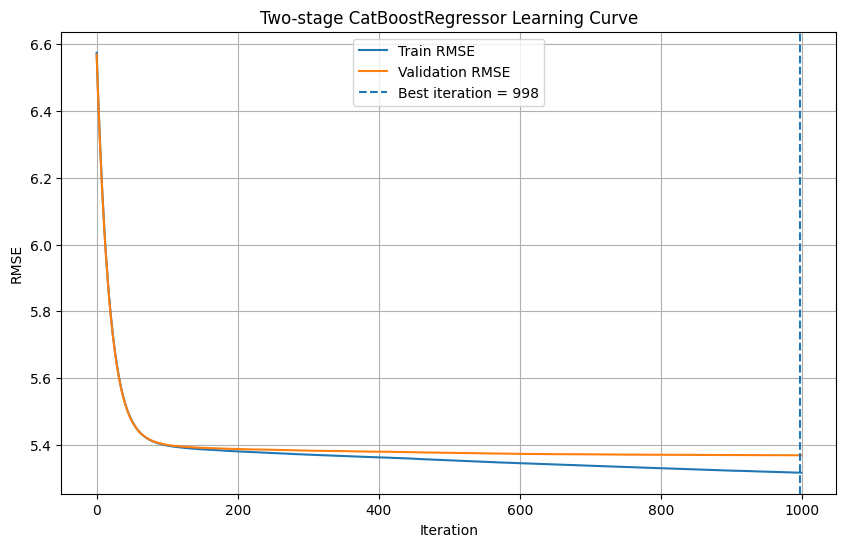

In [41]:
history = reg_model.get_evals_result()

val_key = [key for key in history.keys() if key != "learn"][0]

plt.figure(figsize=(10, 6))

plt.plot(history["learn"]["RMSE"], label="Train RMSE")
plt.plot(history[val_key]["RMSE"], label="Validation RMSE")

best_iter = reg_model.get_best_iteration()

plt.axvline(
    best_iter,
    linestyle="--",
    label=f"Best iteration = {best_iter}"
)

plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("Two-stage CatBoostRegressor Learning Curve")
plt.legend()
plt.grid(True)

plt.show()

Видим, что после 800 итераций кривая валидации выходит на плато, останавливаем обучение на 1000 итераций

Предсказание на тестовой выборке

In [42]:
test_pool_reg = Pool(
    X_test_stage2,
    y_test,
    cat_features=cat_features_stage2
)

y_pred_log_raw = reg_model.predict(test_pool_reg)

upper_pred_log = model_data["log_target"].quantile(0.999)

y_pred_log = np.clip(
    y_pred_log_raw,
    0,
    upper_pred_log
)

y_true_log = y_test.values

### Метрики итогового алгоритма

Метрики качества:

In [45]:
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_true_log)

mae_log = mean_absolute_error(y_true_log, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
r2_log = r2_score(y_true_log, y_pred_log)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

over_15 = (
    y_pred > 1.5 * np.maximum(y_true, 1)
).mean()

under_15 = (
    y_pred < y_true / 1.5
).mean()

print("Two-stage Algorithm metrics in log-space")
print(f"MAE log:  {mae_log:.4f}")
print(f"RMSE log: {rmse_log:.4f}")
print(f"R2 log:   {r2_log:.4f}")

print("\nTwo-stage Algorithm metrics in original scale")
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

print("\nBusiness metrics")
print(f"Overestimation > 1.5x:  {over_15:.2%}")
print(f"Underestimation > 1.5x: {under_15:.2%}")

Two-stage Algorithm metrics in log-space
MAE log:  4.4926
RMSE log: 5.3891
R2 log:   0.3408

Two-stage Algorithm metrics in original scale
MAE:  1,693,638.01
RMSE: 7,790,036.81

Business metrics
Overestimation > 1.5x:  42.85%
Underestimation > 1.5x: 44.79%


Сравнение с алгоритмом с временными признаками

In [46]:
comparison = pd.DataFrame([
    {
        "model": "Temporal Algorithm",
        "mae_log": 4.5083,
        "rmse_log": 5.3850,
        "r2_log": 0.3418,
        "mae": 1_739_091.40,
        "rmse": 7_796_200.74,
        "over_15": 0.4372,
        "under_15": 0.4584
    },
    {
        "model": "Two-stage Algorithm",
        "mae_log": mae_log,
        "rmse_log": rmse_log,
        "r2_log": r2_log,
        "mae": mae,
        "rmse": rmse,
        "over_15": over_15,
        "under_15": under_15
    }
])

comparison

,model,mae_log,rmse_log,r2_log,mae,rmse,over_15,under_15
0,Temporal Algorithm,4.51,5.38,0.34,1739091.40,7796200.74,0.44,0.46
1,Two-stage Algorithm,4.49,5.39,0.34,1693638.01,7790036.81,0.43,0.45


Графики

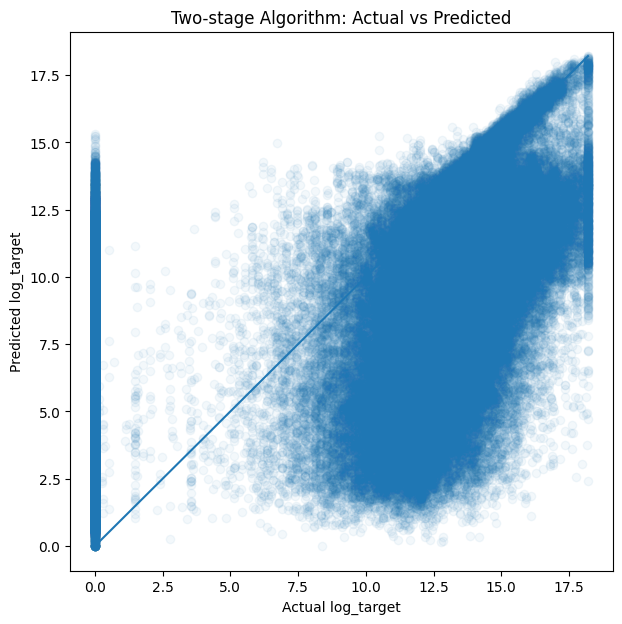

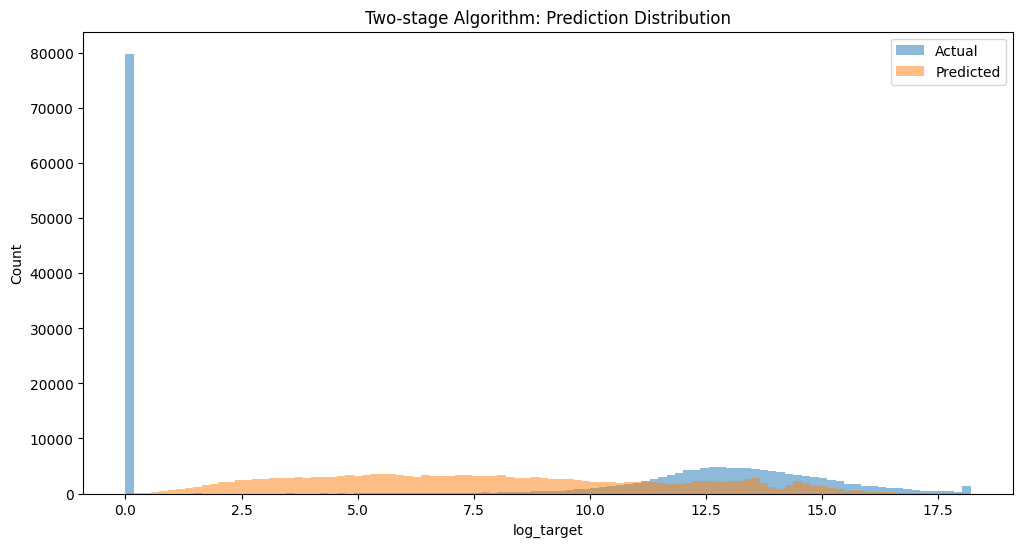

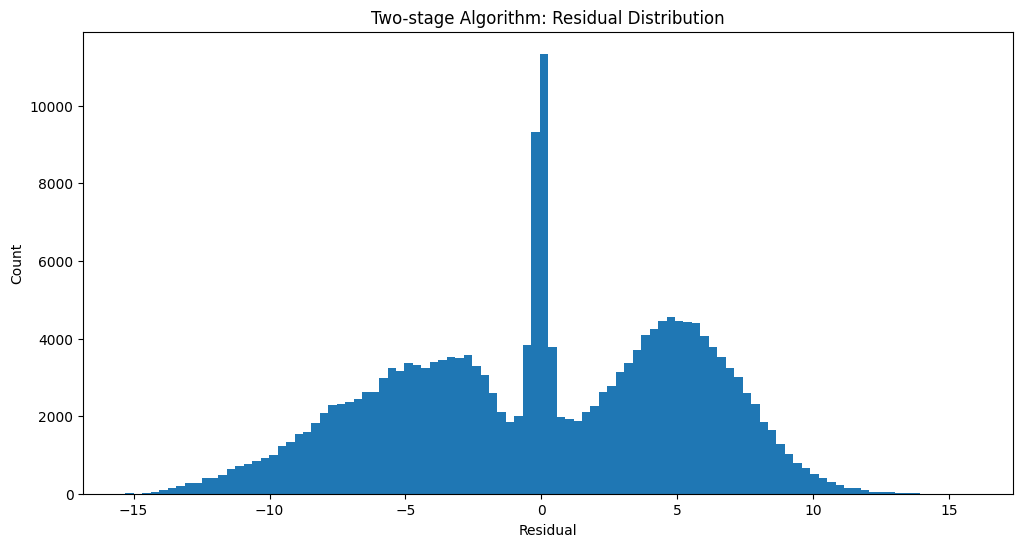

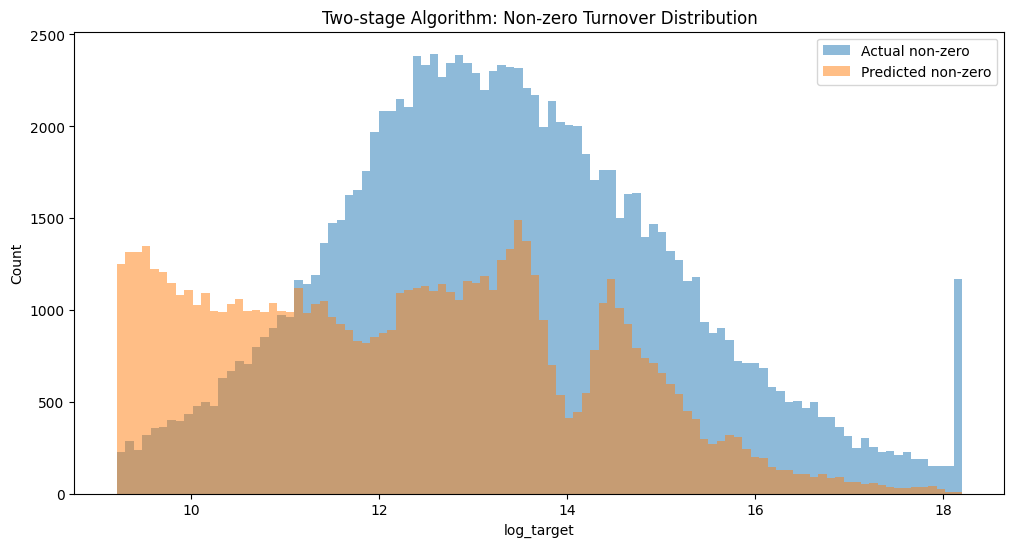

In [48]:
plot_actual_vs_predicted(
    y_true_log,
    y_pred_log,
    model_name="Two-stage Algorithm"
)

plot_prediction_distribution(
    y_true_log,
    y_pred_log,
    model_name="Two-stage Algorithm"
)

plot_residual_distribution(
    y_true_log,
    y_pred_log,
    model_name="Two-stage Algorithm"
)

plot_nonzero_distribution(
    y_true_log,
    y_pred_log,
    model_name="Two-stage Algorithm",
    min_turnover=10000
)

Feature importance:

In [49]:
stage2_features = list(X_train_stage2.columns)

feature_importance = pd.DataFrame({
    "feature": stage2_features,
    "importance": reg_model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(30)

,feature,importance
82,activity_prob_low,31.74
83,activity_prob_medium,15.03
16,company_age,5.53
0,log_income,4.32
9,transaction_cnt,3.89
79,days_since_prev_score,3.77
27,okved_cluster,3.26
17,ip_flg,1.89
84,activity_prob_high,1.71
26,vital_business_flg,1.57


### Выводы

Эксперимент показал, что two-stage approach позволяет улучшить качество прогнозирования оборота по сравнению с базовой temporal-моделью.

Предварительная классификация компаний по уровню финансовой активности помогла регрессионной модели лучше учитывать неоднородность распределения целевой переменной и различия в поведении клиентов. Наибольший вклад в итоговый прогноз внесли признаки activity_prob_low и activity_prob_medium, что подтверждает высокую значимость информации, полученной на этапе классификации.

Кроме того, существенную важность сохранили temporal-признаки, связанные с историей скорингов и динамикой поведения клиентов. Полученные результаты подтверждают эффективность сочетания temporal feature engineering и двухэтапной архитектуры для задач банковского прогнозирования оборота компаний.